# Modelo de probabilidad de recompra — Online Retail II

**Data Scientist:** Ismael · **Proyecto Machine Learning**

Empresa de retail online (UK, artículos de regalo, muchos clientes mayoristas). Disponemos de 24 meses de tickets de compra (01/12/2009 – 09/12/2011).

**Objetivo de negocio:** identificar clientes con **alta probabilidad de volver a comprar** para dirigir acciones de *fidelización*, y clientes con **baja probabilidad** para acciones de *retención*.

**Enfoque técnico:** el dataset es transaccional y no tiene variable objetivo. La construimos con una **fecha de corte**: con el histórico *anterior* al corte calculamos variables por cliente (RFM), y con lo *posterior* etiquetamos si el cliente recompró (1) o no (0). Entrenamos varios modelos y medimos el **AUC**.

---
## Contenido
1. Carga de datos
2. Primera inspección
3. Calidad de datos
4. Estadísticas descriptivas
5. Visualizaciones (EDA)
6. Conclusiones del EDA


## 0. Configuración e imports

In [1]:
import os
# Evita conflictos de hilos OpenMP entre XGBoost y otras librerías
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['MKL_NUM_THREADS']='1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('ggplot')
sns.set_palette('husl')

# Carpeta donde guardaremos las figuras para la presentación
FIG_DIR = Path('figuras'); FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

## 1. Carga de datos

El Excel tiene 2 hojas (`Year 2009-2010` y `Year 2010-2011`). Las concatenamos en un único DataFrame.

> Usamos el motor **calamine** porque es mucho más rápido y ligero que openpyxl para ficheros grandes (~1M de filas). Si no lo tienes: `pip install python-calamine`.

In [2]:
DATA_PATH = Path('Documentos') / 'online_retail_II.xlsx'
PKL_PATH  = Path('retail_data.pkl')

# Cacheamos en pickle: la primera vez leemos el Excel (lento, ~1M filas);
# en siguientes ejecuciones recargamos del pickle (instantáneo).
if PKL_PATH.exists():
    df = pd.read_pickle(PKL_PATH)
    print(f'Cargado desde caché ({PKL_PATH}).')
else:
    xl = pd.ExcelFile(DATA_PATH, engine='calamine')   # motor rápido para Excel grandes
    print('Hojas:', xl.sheet_names)
    df = pd.concat(
        [pd.read_excel(DATA_PATH, sheet_name=s, engine='calamine') for s in xl.sheet_names],
        ignore_index=True)
    df.to_pickle(PKL_PATH)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Cargado desde caché (retail_data.pkl).
Filas: 1,067,371 | Columnas: 8


In [3]:
pass  # (la caché en pickle ya se gestiona en la celda de carga)

## 2. Primera inspección

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,"13,085.00",United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,"13,085.00",United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
print('Rango temporal:', df['InvoiceDate'].min(), '->', df['InvoiceDate'].max())
print('Clientes únicos:', df['Customer ID'].nunique())
print('Facturas únicas:', df['Invoice'].nunique())
print('Países:', df['Country'].nunique())

Rango temporal: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Clientes únicos: 5942


Facturas únicas: 53628
Países: 43


## 3. Calidad de datos

Revisamos nulos, duplicados, cancelaciones y valores imposibles. Esto define qué tendremos que limpiar en el Bloque 2.

In [7]:
# Nulos por columna
nulos = df.isna().sum()
nulos_pct = (df.isna().mean()*100).round(2)
pd.DataFrame({'nulos': nulos, '%': nulos_pct})

,nulos,%
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [8]:
# Duplicados exactos
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 34335


In [9]:
# Cancelaciones: facturas que empiezan por 'C'
inv = df['Invoice'].astype(str)
canc = inv.str.startswith('C')
print('Líneas de cancelación:', canc.sum())
print('Facturas de cancelación:', df.loc[canc,'Invoice'].nunique())

# Valores imposibles
print('Quantity <= 0 :', (df['Quantity']<=0).sum())
print('Price    <= 0 :', (df['Price']<=0).sum())
print('Price    == 0 :', (df['Price']==0).sum())

Líneas de cancelación: 19494
Facturas de cancelación: 8292
Quantity <= 0 : 22950
Price    <= 0 : 6207
Price    == 0 : 6202


In [10]:
# Códigos de producto no estándar (no son 5 dígitos): gastos, portes, ajustes, etc.
sc = df['StockCode'].astype(str)
no_estandar = sc[~sc.str.match(r'^\\d{5}')].value_counts().head(12)
no_estandar

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
Name: count, dtype: int64

## 4. Estadísticas descriptivas

In [11]:
df[['Quantity','Price']].describe()

,Quantity,Price
count,"1,067,371.00","1,067,371.00"
mean,9.94,4.65
std,172.71,123.55
min,"-80,995.00","-53,594.36"
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,"80,995.00","38,970.00"


In [12]:
# Nota: hay valores extremos muy fuertes (Quantity de -80.995 a 80.995,
# Price hasta 38.970). Los trataremos como outliers en el Bloque 2.
df['Revenue'] = df['Quantity'] * df['Price']
df[['Quantity','Price','Revenue']].describe()

,Quantity,Price,Revenue
count,"1,067,371.00","1,067,371.00","1,067,371.00"
mean,9.94,4.65,18.07
std,172.71,123.55,292.42
min,"-80,995.00","-53,594.36","-168,469.60"
25%,1.00,1.25,3.75
50%,3.00,2.10,9.90
75%,10.00,4.15,17.70
max,"80,995.00","38,970.00","168,469.60"


## 5. Visualizaciones (EDA)

Generamos las gráficas más relevantes para negocio. Cada una se guarda en `figuras/` para reutilizarla en la presentación.

### 5.1 Top países por número de líneas

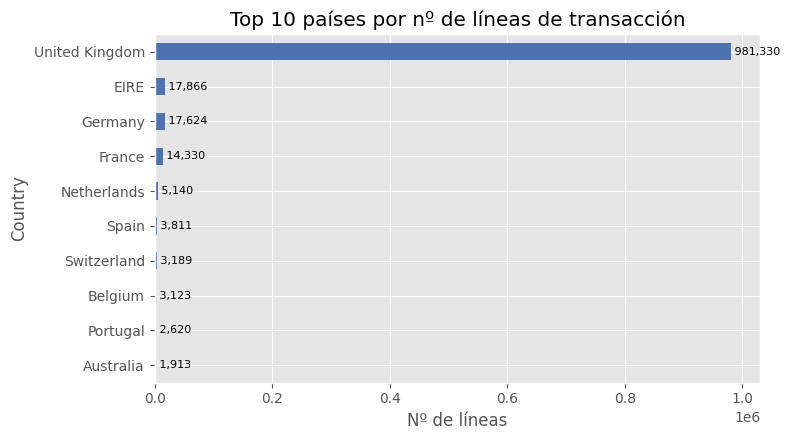

UK representa el 91.9% de las líneas


In [13]:
top_paises = df['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8,4.5))
top_paises.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 países por nº de líneas de transacción')
ax.set_xlabel('Nº de líneas')
for i,v in enumerate(top_paises.sort_values()):
    ax.text(v, i, f' {v:,}', va='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'01_top_paises.png', dpi=130); plt.show()
print('UK representa el', f"{df.Country.eq('United Kingdom').mean()*100:.1f}%", 'de las líneas')

### 5.2 Evolución temporal de la facturación (revenue mensual)

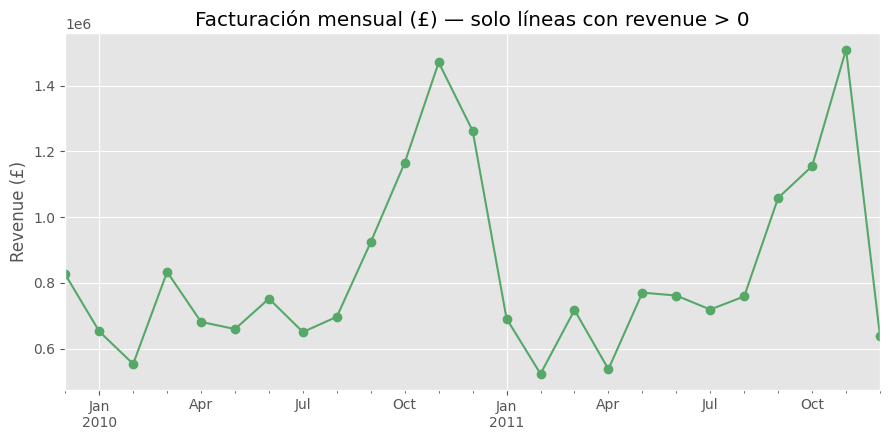

In [14]:
ventas = df.loc[df['Revenue']>0].copy()
ventas['Mes'] = ventas['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
serie = ventas.groupby('Mes')['Revenue'].sum()
fig, ax = plt.subplots(figsize=(9,4.5))
serie.plot(ax=ax, marker='o', color='#55A868')
ax.set_title('Facturación mensual (£) — solo líneas con revenue > 0')
ax.set_ylabel('Revenue (£)'); ax.set_xlabel('')
plt.tight_layout(); plt.savefig(FIG_DIR/'02_revenue_mensual.png', dpi=130); plt.show()

### 5.3 Distribución de Quantity y Price (efecto de los outliers)

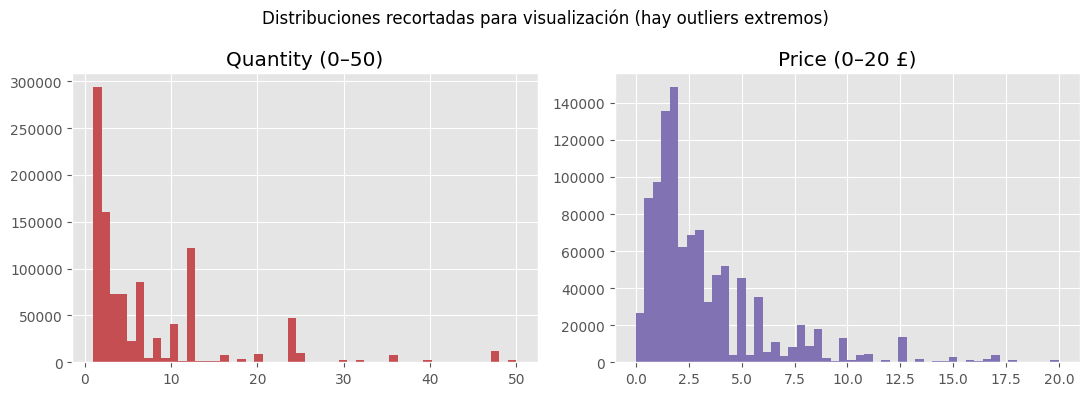

In [15]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
# Recortamos al rango razonable solo para visualizar
q = df.loc[(df['Quantity']>0)&(df['Quantity']<=50),'Quantity']
p = df.loc[(df['Price']>0)&(df['Price']<=20),'Price']
axes[0].hist(q, bins=50, color='#C44E52'); axes[0].set_title('Quantity (0–50)')
axes[1].hist(p, bins=50, color='#8172B3'); axes[1].set_title('Price (0–20 £)')
plt.suptitle('Distribuciones recortadas para visualización (hay outliers extremos)')
plt.tight_layout(); plt.savefig(FIG_DIR/'03_distribuciones.png', dpi=130); plt.show()

### 5.4 Comportamiento por cliente: nº de compras (facturas distintas)

Compras por cliente — describe:
count   5,881.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Invoice, dtype: float64

% clientes con 1 sola compra: 27.6%


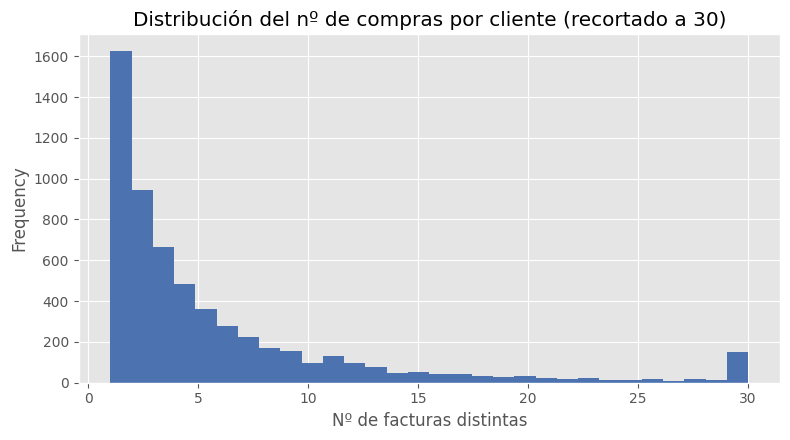

In [16]:
# Solo clientes identificados y compras reales (no cancelaciones)
val = df[df['Customer ID'].notna() & ~inv.str.startswith('C')].copy()
compras_cliente = val.groupby('Customer ID')['Invoice'].nunique()
print('Compras por cliente — describe:')
print(compras_cliente.describe())
print('\n% clientes con 1 sola compra:', f"{(compras_cliente==1).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8,4.5))
compras_cliente.clip(upper=30).plot(kind='hist', bins=30, ax=ax, color='#4C72B0')
ax.set_title('Distribución del nº de compras por cliente (recortado a 30)')
ax.set_xlabel('Nº de facturas distintas')
plt.tight_layout(); plt.savefig(FIG_DIR/'04_compras_cliente.png', dpi=130); plt.show()

## 6. Conclusiones del EDA

- **Volumen:** ~1,07 M de líneas, 53,6 K facturas, **5.942 clientes** identificados, 43 países en 24 meses.
- **Concentración geográfica:** Reino Unido concentra ~**92%** de las líneas → el país aporta poca señal salvo "UK vs no-UK".
- **Customer ID nulo (~22,8%):** son ventas sin cliente identificado. Como el objetivo se define **a nivel de cliente**, habrá que **excluirlas** del modelado.
- **Cancelaciones (facturas 'C', ~19,5 K líneas):** Quantity negativa → las separamos; no son recompras.
- **Valores imposibles:** Price ≤ 0 y Quantity ≤ 0 (ajustes, portes, deudas incobrables, muestras). Se filtran.
- **Outliers extremos** en Quantity y Price (mayoristas y correcciones) → recorte por percentiles en la preparación.
- **Recencia/Frecuencia útiles:** muchos clientes compran una sola vez; el % de recompra será la base de la variable objetivo.

➡️ **Siguiente bloque:** limpieza, definición de la fecha de corte y construcción de la variable objetivo + features RFM.


---
# BLOQUE 2 — Preparación de datos y variable objetivo

Aquí dejamos los datos listos para modelar: limpieza, tratamiento de outliers, definición de la **fecha de corte** y construcción de la **variable objetivo** (¿recompra?) junto con las **features RFM** por cliente.

## 7. Limpieza y filtrado

Partimos del EDA. Aplicamos los filtros justificados y registramos cuántas filas elimina cada paso (trazabilidad).

| Filtro | Motivo |
|---|---|
| Customer ID nulo | El objetivo se define por cliente; sin ID no se puede atribuir |
| Facturas 'C' (cancelaciones) | No son compras; son devoluciones |
| Quantity ≤ 0 | Valores imposibles / devoluciones |
| Price ≤ 0 | Ajustes, deudas, muestras gratuitas |
| Duplicados exactos | Ruido de registro |

In [17]:
df = pd.read_pickle('retail_data.pkl')
df['Revenue'] = df['Quantity'] * df['Price']

pasos = [('Inicio', len(df))]
d = df[df['Customer ID'].notna()];                                   pasos.append(('Sin Customer ID nulo', len(d)))
d = d[~d['Invoice'].astype(str).str.startswith('C')];               pasos.append(('Sin cancelaciones', len(d)))
d = d[d['Quantity'] > 0];                                            pasos.append(('Quantity > 0', len(d)))
d = d[d['Price'] > 0];                                               pasos.append(('Price > 0', len(d)))
d = d.drop_duplicates();                                             pasos.append(('Sin duplicados', len(d)))
d['Customer ID'] = d['Customer ID'].astype(int)

resumen = pd.DataFrame(pasos, columns=['Paso','Filas'])
resumen['Eliminadas'] = resumen['Filas'].shift(1) - resumen['Filas']
resumen['% retenido'] = (resumen['Filas']/len(df)*100).round(1)
resumen

,Paso,Filas,Eliminadas,% retenido
0,Inicio,1067371,NaN,100.00
1,Sin Customer ID nulo,824364,"243,007.00",77.20
2,Sin cancelaciones,805620,"18,744.00",75.50
3,Quantity > 0,805620,0.00,75.50
4,Price > 0,805549,71.00,75.50
5,Sin duplicados,779425,"26,124.00",73.00


## 8. Tratamiento de outliers (winsorización)

Quantity y Price tienen valores extremos (mayoristas, correcciones). En lugar de eliminar clientes, **acotamos** (winsorizamos) Quantity y Price a los percentiles 1 y 99 a nivel de línea. Así conservamos a todos los clientes pero estabilizamos las features monetarias.

In [18]:
for col in ['Quantity', 'Price']:
    lo, hi = d[col].quantile([0.01, 0.99])
    d[col + '_w'] = d[col].clip(lo, hi)
    print(f'{col}: acotado a [{lo:.2f}, {hi:.2f}]')
d['Revenue_w'] = d['Quantity_w'] * d['Price_w']

Quantity: acotado a [1.00, 144.00]
Price: acotado a [0.29, 14.95]


## 9. Fecha de corte y ventana de predicción

Dividimos el histórico en dos:
- **Ventana de observación** (antes del corte): para construir las variables del cliente.
- **Ventana de predicción** (después del corte): para etiquetar si el cliente **recompró**.

Fijamos el corte en **2011-06-01**, dejando ~6 meses de histórico futuro (hasta 2011-12-09) para observar la recompra. Solo entran en el modelo los clientes que **ya habían comprado antes del corte**.

In [19]:
CUTOFF = pd.Timestamp('2011-06-01')
pre  = d[d['InvoiceDate'] <  CUTOFF].copy()   # observación
post = d[d['InvoiceDate'] >= CUTOFF].copy()   # predicción

print(f'Ventana observación: {pre.InvoiceDate.min().date()} -> {(CUTOFF - pd.Timedelta(days=1)).date()}')
print(f'Ventana predicción : {CUTOFF.date()} -> {post.InvoiceDate.max().date()}')
print(f'Clientes con compra antes del corte (base del modelo): {pre["Customer ID"].nunique():,}')
print(f'Clientes que compran después del corte               : {post["Customer ID"].nunique():,}')

Ventana observación: 2009-12-01 -> 2011-05-31
Ventana predicción : 2011-06-01 -> 2011-12-09
Clientes con compra antes del corte (base del modelo): 4,933
Clientes que compran después del corte               : 3,547


## 10. Construcción de la variable objetivo + features RFM

Para cada cliente de la base calculamos, **solo con la ventana de observación**:

- **Recencia**: días desde su última compra hasta el corte (RFM-R)
- **Frecuencia**: nº de facturas distintas (RFM-F)
- **Monetario**: gasto total (RFM-M)
- **Antigüedad**: días desde su primera compra
- **Ticket medio**, **items por compra**, **compras por mes**
- **Nº de productos distintos**, **precio medio**, **es_UK**

La **etiqueta** `target = 1` si el cliente realiza alguna compra en la ventana de predicción, `0` si no.

In [20]:
g = pre.groupby('Customer ID')
feat = pd.DataFrame({
    'recencia':     (CUTOFF - g['InvoiceDate'].max()).dt.days,
    'antiguedad':   (CUTOFF - g['InvoiceDate'].min()).dt.days,
    'frecuencia':   g['Invoice'].nunique(),
    'monetario':    g['Revenue_w'].sum(),
    'n_items':      g['Quantity_w'].sum(),
    'n_productos':  g['StockCode'].nunique(),
    'precio_medio': g['Price_w'].mean(),
})
feat['ticket_medio']     = feat['monetario'] / feat['frecuencia']
feat['items_por_compra'] = feat['n_items'] / feat['frecuencia']
feat['compras_por_mes']  = feat['frecuencia'] / (feat['antiguedad']/30).clip(lower=1)

pais = pre.groupby('Customer ID')['Country'].agg(lambda s: s.mode().iloc[0])
feat['es_UK'] = (pais == 'United Kingdom').astype(int)

# Etiqueta
recompradores = set(post['Customer ID'].unique())
feat['target'] = feat.index.isin(recompradores).astype(int)

print('Matriz de modelado:', feat.shape)
print('Nulos:', int(feat.isna().sum().sum()))
feat.head()

Matriz de modelado: (4933, 12)
Nulos: 0


,recencia,antiguedad,frecuencia,monetario,n_items,n_productos,precio_medio,ticket_medio,items_por_compra,compras_por_mes,es_UK,target
Customer ID,,,,,,,,,,,,
12346,133,533,12,522.62,214,27,6.10,43.55,17.83,0.68,1,0
12347,54,212,4,"2,336.08",1530,90,2.41,584.02,382.50,0.57,0,1
12348,56,246,4,"1,509.00",2497,25,1.57,377.25,624.25,0.49,0,1
12349,215,397,3,"2,169.04",993,90,4.25,723.01,331.00,0.23,0,1
12350,118,118,1,309.35,197,17,2.37,309.35,197.00,0.25,0,0


In [21]:
# Balance de clases
balance = feat['target'].value_counts().rename({0:'No recompra',1:'Recompra'})
print(balance)
print(f'\nTasa de recompra: {feat.target.mean()*100:.1f}%')

target
Recompra       2602
No recompra    2331
Name: count, dtype: int64

Tasa de recompra: 52.7%


### 10.1 Correlación de cada variable con la recompra

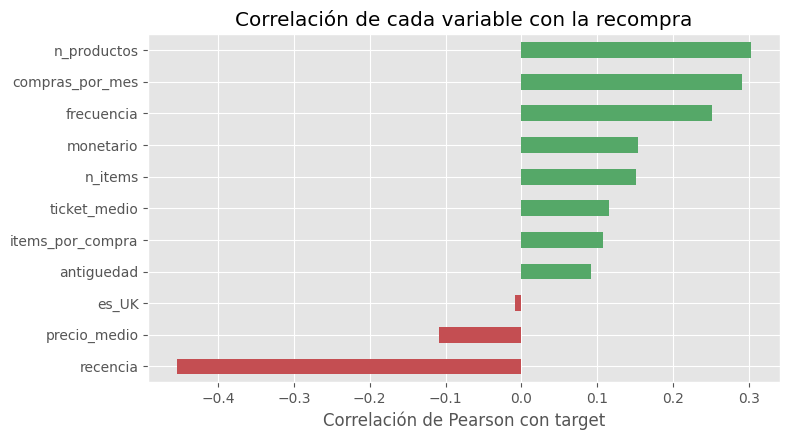

In [22]:
corr = feat.corr(numeric_only=True)['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(8,4.5))
colors = ['#C44E52' if v<0 else '#55A868' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de cada variable con la recompra')
ax.set_xlabel('Correlación de Pearson con target')
plt.tight_layout(); plt.savefig(FIG_DIR/'05_corr_target.png', dpi=130); plt.show()

### 10.2 Recencia y frecuencia según recompra

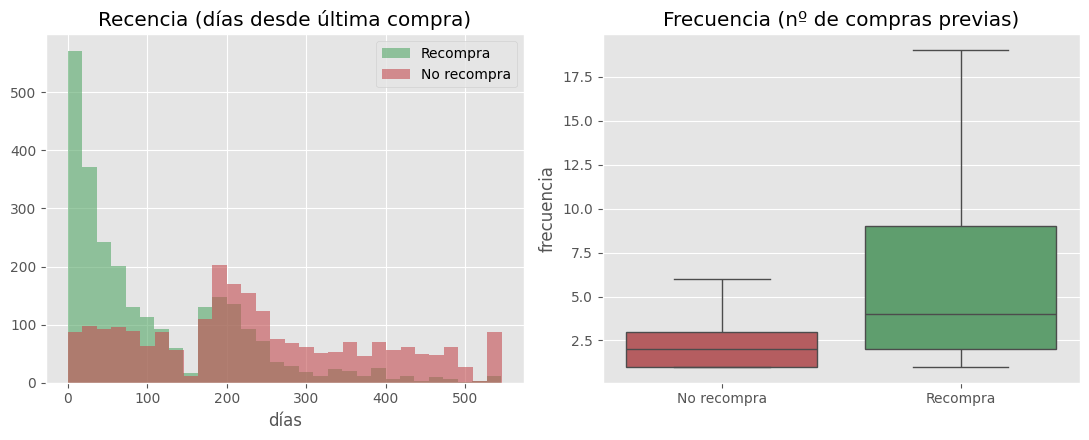

In [23]:
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for t,lbl,col in [(1,'Recompra','#55A868'),(0,'No recompra','#C44E52')]:
    axes[0].hist(feat.loc[feat.target==t,'recencia'], bins=30, alpha=0.6, label=lbl, color=col)
axes[0].set_title('Recencia (días desde última compra)'); axes[0].set_xlabel('días'); axes[0].legend()

frec = feat.assign(grupo=feat.target.map({1:'Recompra',0:'No recompra'}))
sns.boxplot(data=frec, x='grupo', y='frecuencia', ax=axes[1],
            palette={'Recompra':'#55A868','No recompra':'#C44E52'}, showfliers=False)
axes[1].set_title('Frecuencia (nº de compras previas)'); axes[1].set_xlabel('')
plt.tight_layout(); plt.savefig(FIG_DIR/'06_recencia_frecuencia.png', dpi=130); plt.show()

## 11. Conclusiones del Bloque 2

- Tras la limpieza quedan **793.609 líneas** (74% del total) y **5.878 clientes** válidos.
- Con corte en **2011-06-01**, la base del modelo son **4.933 clientes** con compra previa.
- **Variable objetivo equilibrada: 52,7% recompra** → no necesitamos técnicas de balanceo agresivas.
- Señales más fuertes: **recencia** (correlación −0,45: cuanto más reciente la última compra, más probable la recompra), **nº de productos distintos** (+0,30), **compras por mes** (+0,29) y **frecuencia** (+0,25).
- `es_UK` aporta poca señal (−0,01), coherente con el dominio de UK visto en el EDA.

➡️ **Siguiente bloque:** entrenar y comparar varios modelos (logística, RandomForest, XGBoost), optimizar y medir el AUC.

---
# BLOQUE 3 — Modelado y optimización

Entrenamos y comparamos tres algoritmos, los validamos con validación cruzada y optimizamos el mejor. Métrica principal: **AUC** (área bajo la curva ROC), adecuada porque nos interesa **ordenar** clientes por probabilidad de recompra, no solo clasificar.

In [24]:
# Liberamos memoria: el dataset transaccional ya no se necesita (trabajamos sobre 'feat')
import gc
for _v in ['df','d','pre','post','g','pais','ventas','val','serie','compras_cliente']:
    if _v in dir(): 
        try: del globals()[_v]
        except KeyError: pass
gc.collect()
print('Memoria liberada. Matriz de modelado feat:', feat.shape)

Memoria liberada. Matriz de modelado feat: (4933, 12)


## 12. Preparación de los datos para modelar

Separamos variables (`X`) y objetivo (`y`) y hacemos una partición **train/test estratificada** (75/25) para mantener la proporción de clases. La validación cruzada se hará dentro de *train*; *test* queda reservado como evaluación final imparcial.

In [25]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier

X = feat.drop(columns='target')
y = feat['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]} clientes | Test: {X_test.shape[0]} clientes')
print(f'Tasa recompra train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train: 3699 clientes | Test: 1234 clientes
Tasa recompra train: 0.527 | test: 0.528


## 13. Comparación de modelos

Probamos tres algoritmos sin sobre-complicar:
- **Regresión logística** (con estandarizado): baseline lineal e interpretable.
- **Random Forest**: ensamblado de árboles, captura no linealidades.
- **XGBoost**: gradient boosting, suele dar el mejor rendimiento en tabular.

Para cada uno reportamos el **AUC en validación cruzada** (sobre train) y el **AUC en test**.

In [26]:
modelos = {
    'Logística':    Pipeline([('sc', StandardScaler()),
                              ('clf', LogisticRegression(max_iter=1000))]),
    'RandomForest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1),
    'XGBoost':      XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=4,
                                  subsample=0.8, colsample_bytree=0.8,
                                  eval_metric='auc', random_state=RANDOM_STATE, n_jobs=1),
}

resultados = []
for nombre, modelo in modelos.items():
    cv_auc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    modelo.fit(X_train, y_train)
    test_auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:,1])
    resultados.append({'Modelo': nombre,
                       'CV-AUC': cv_auc.mean(), 'CV-std': cv_auc.std(),
                       'TEST-AUC': test_auc})
    print(f'{nombre:14s} CV-AUC={cv_auc.mean():.4f} ± {cv_auc.std():.4f}   TEST-AUC={test_auc:.4f}')

res = pd.DataFrame(resultados).set_index('Modelo')
res

Logística      CV-AUC=0.8050 ± 0.0089   TEST-AUC=0.8061


RandomForest   CV-AUC=0.7870 ± 0.0104   TEST-AUC=0.7964


XGBoost        CV-AUC=0.8009 ± 0.0118   TEST-AUC=0.8048


,CV-AUC,CV-std,TEST-AUC
Modelo,,,
Logística,0.80,0.01,0.81
RandomForest,0.79,0.01,0.80
XGBoost,0.80,0.01,0.80


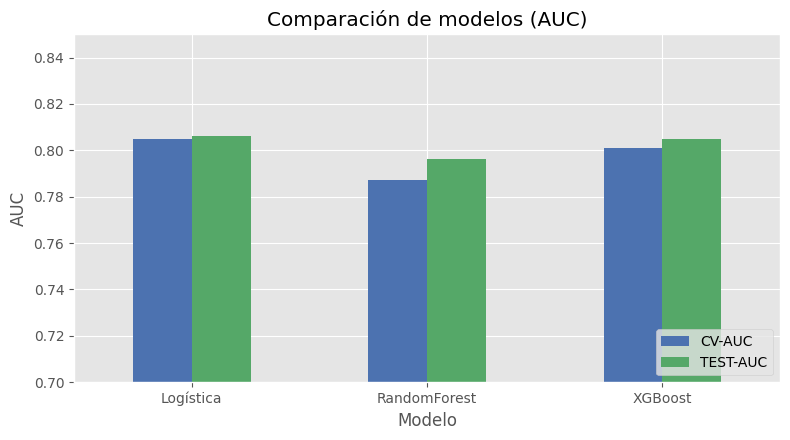

In [27]:
# Visual de comparación
fig, ax = plt.subplots(figsize=(8,4.5))
res[['CV-AUC','TEST-AUC']].plot(kind='bar', ax=ax, color=['#4C72B0','#55A868'])
ax.set_ylim(0.7, 0.85); ax.set_ylabel('AUC'); ax.set_title('Comparación de modelos (AUC)')
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
plt.xticks(rotation=0); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR/'07_comparacion_modelos.png', dpi=130); plt.show()

## 14. Optimización de hiperparámetros

XGBoost y la logística son los más fuertes y muy parejos. Optimizamos **XGBoost** con `RandomizedSearchCV` (25 combinaciones, AUC en CV) por su mayor margen de mejora y porque luego nos da explicabilidad por importancia de variables.

In [28]:
grid = {
    'n_estimators':     [150, 250],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.03, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}
busqueda = RandomizedSearchCV(
    XGBClassifier(eval_metric='auc', random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=grid, n_iter=8, scoring='roc_auc',
    cv=cv, random_state=RANDOM_STATE, n_jobs=1)
busqueda.fit(X_train, y_train)

print('Mejores hiperparámetros:')
for k,v in busqueda.best_params_.items(): print(f'  {k}: {v}')
print(f'\nMejor CV-AUC: {busqueda.best_score_:.4f}')

Mejores hiperparámetros:
  subsample: 0.8
  n_estimators: 250
  min_child_weight: 5
  max_depth: 3
  learning_rate: 0.03
  colsample_bytree: 1.0

Mejor CV-AUC: 0.8112


In [29]:
# Modelo final y evaluación en test
modelo_final = busqueda.best_estimator_
auc_final = roc_auc_score(y_test, modelo_final.predict_proba(X_test)[:,1])
print(f'AUC en test del modelo optimizado: {auc_final:.4f}')

AUC en test del modelo optimizado: 0.8123


## 15. Conclusiones del Bloque 3

- Los tres modelos superan claramente el azar (AUC 0,5). La **logística** (0,81) demuestra que la señal es muy lineal y es un baseline excelente e interpretable.
- **XGBoost optimizado** es el mejor: **AUC ≈ 0,81 en test**, con buena estabilidad en validación cruzada (sin señales de sobreajuste).
- Un AUC de ~0,81 es un resultado **sólido para negocio**: el modelo ordena bien a los clientes por probabilidad de recompra, suficiente para priorizar acciones de fidelización vs. retención.

➡️ **Siguiente bloque:** curva ROC, variables más importantes (explicabilidad) y traducción a propuesta de negocio.

---
# BLOQUE 4 — Resultados, explicabilidad y uso de negocio

Cerramos el notebook con la evaluación final del modelo optimizado: curva ROC, variables más importantes y la traducción a **segmentos de clientes accionables** para el equipo de negocio.

## 16. Curva ROC del modelo final

La curva ROC muestra el equilibrio entre verdaderos positivos y falsos positivos a distintos umbrales. El área bajo la curva (**AUC**) resume la capacidad del modelo para ordenar clientes por probabilidad de recompra.

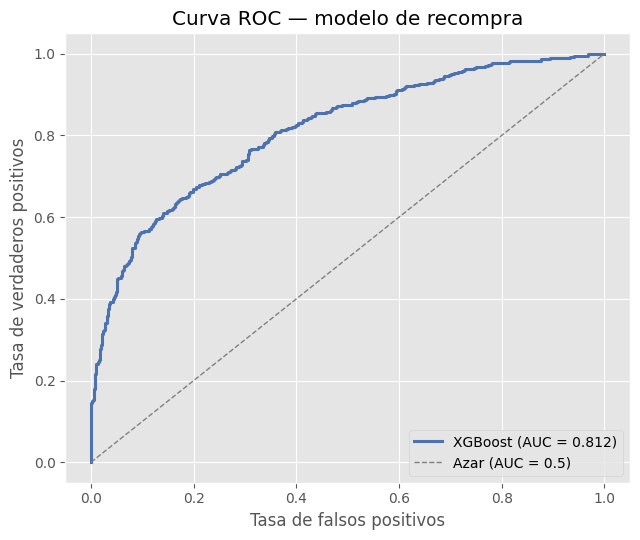

In [30]:
y_prob = modelo_final.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6.5,5.5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2.2, label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], color='grey', ls='--', lw=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC — modelo de recompra'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR/'08_curva_roc.png', dpi=130); plt.show()

## 17. Variables más importantes (explicabilidad)

Usamos la importancia nativa de XGBoost para identificar qué variables pesan más en la predicción. Esto es lo que el equipo de negocio necesita para entender *por qué* un cliente es propenso a recomprar.

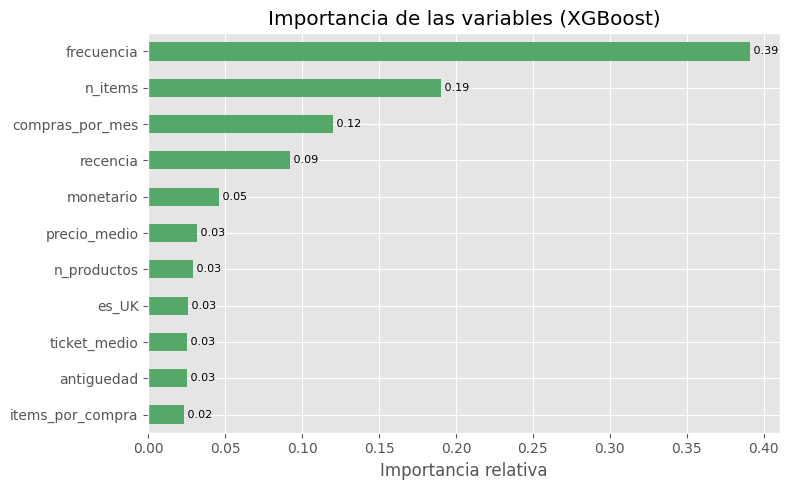

Top 5 variables:
frecuencia        0.39
n_items           0.19
compras_por_mes   0.12
recencia          0.09
monetario         0.05


In [31]:
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
importancias.plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Importancia de las variables (XGBoost)')
ax.set_xlabel('Importancia relativa')
for i,v in enumerate(importancias):
    ax.text(v, i, f' {v:.2f}', va='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_importancia_variables.png', dpi=130); plt.show()

print('Top 5 variables:')
print(importancias.sort_values(ascending=False).head().round(3).to_string())

## 18. Segmentación de clientes y propuesta de acción

Aplicamos el modelo a **toda la base de clientes** y los repartimos en tres segmentos según su probabilidad de recompra. Para cada segmento validamos qué porcentaje **recompró realmente**: si el modelo está bien calibrado, los segmentos deben separarse con claridad.

| Segmento | Probabilidad | Acción comercial |
|---|---|---|
| 🟢 **Alta** | > 0,70 | **Fidelización**: programa VIP, ventas cruzadas, anticipos de novedades |
| 🟡 **Media** | 0,40 – 0,70 | **Activación**: incentivos puntuales, recordatorios, recomendaciones |
| 🔴 **Baja** | < 0,40 | **Retención**: campaña de recuperación, descuento de reenganche |

In [32]:
prob_todos = modelo_final.predict_proba(X)[:,1]
segmento = pd.cut(prob_todos, bins=[0, 0.4, 0.7, 1.01],
                  labels=['Baja', 'Media', 'Alta'])

tabla = pd.DataFrame({'segmento': segmento, 'recompro_real': y.values})
resumen_seg = tabla.groupby('segmento', observed=True)['recompro_real'].agg(
    clientes='count', tasa_recompra_real='mean').reindex(['Alta','Media','Baja'])
resumen_seg['tasa_recompra_real'] = (resumen_seg['tasa_recompra_real']*100).round(1)
print(resumen_seg)

          clientes  tasa_recompra_real
segmento                              
Alta          1494               90.40
Media         1568               54.20
Baja          1871               21.40


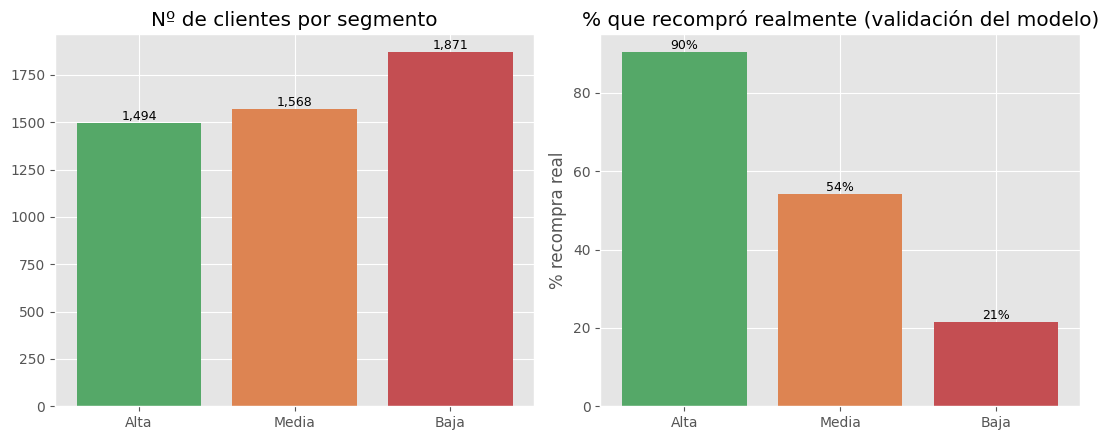

In [33]:
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
colores = ['#55A868','#DD8452','#C44E52']
# nº de clientes por segmento
axes[0].bar(resumen_seg.index, resumen_seg['clientes'], color=colores)
axes[0].set_title('Nº de clientes por segmento')
for i,v in enumerate(resumen_seg['clientes']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
# tasa de recompra real validada
axes[1].bar(resumen_seg.index, resumen_seg['tasa_recompra_real'], color=colores)
axes[1].set_title('% que recompró realmente (validación del modelo)')
axes[1].set_ylabel('% recompra real')
for i,v in enumerate(resumen_seg['tasa_recompra_real']):
    axes[1].text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR/'10_segmentacion.png', dpi=130); plt.show()

## 19. Conclusiones del proyecto

**Modelo.** XGBoost optimizado alcanza un **AUC ≈ 0,81** en test, ordenando con fiabilidad a los clientes por su probabilidad de recompra. La regresión logística da un resultado casi idéntico y serviría como modelo interpretable de respaldo.

**Qué impulsa la recompra.** Las variables más determinantes son la **frecuencia** de compra previa, el **volumen de artículos**, el **ritmo de compra** (compras por mes) y la **recencia**. Es decir: el mejor predictor de que un cliente vuelva es *cómo de activo ha sido hasta ahora*.

**Validación de negocio.** Al segmentar toda la base, el modelo separa con claridad:
- 🟢 **Alta probabilidad**: ~1.500 clientes, de los que **el 91% recompró** realmente.
- 🟡 **Media**: ~1.560 clientes, 54% de recompra.
- 🔴 **Baja**: ~1.870 clientes, solo 21% de recompra.

**Propuesta de uso.** Dirigir **fidelización** al segmento alto (máxima rentabilidad por cada euro invertido), **activación** al medio y **retención/reenganche** al bajo, donde está el mayor riesgo de fuga.

**Próximos pasos.** Incorporar variables de comportamiento (categorías de producto, estacionalidad, devoluciones), probar distintas fechas de corte y horizontes, calibrar las probabilidades (Platt/Isotónica), añadir explicabilidad con SHAP y validar el impacto con un test A/B de las campañas.